In [88]:
import pandas as pd
import numpy as np
import datetime
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
from sklearn.cluster import KMeans
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np


---

### 26. Carregamento e inspeção inicial Carregue o dataset no Pandas. Liste tipos de dados e estatísticas descritivas (.info() e .describe()).

In [89]:
df_energy_data = pd.read_csv('./data/energydata_complete.csv')

df_energy_data['date'] = pd.to_datetime(df_energy_data['date'])

df_energy_data.info()
df_energy_data.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19735 entries, 0 to 19734
Data columns (total 29 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   date         19735 non-null  datetime64[ns]
 1   Appliances   19735 non-null  int64         
 2   lights       19735 non-null  int64         
 3   T1           19735 non-null  float64       
 4   RH_1         19735 non-null  float64       
 5   T2           19735 non-null  float64       
 6   RH_2         19735 non-null  float64       
 7   T3           19735 non-null  float64       
 8   RH_3         19735 non-null  float64       
 9   T4           19735 non-null  float64       
 10  RH_4         19735 non-null  float64       
 11  T5           19735 non-null  float64       
 12  RH_5         19735 non-null  float64       
 13  T6           19735 non-null  float64       
 14  RH_6         19735 non-null  float64       
 15  T7           19735 non-null  float64       
 16  RH_7

,date,Appliances,lights,T1,RH_1,T2,RH_2,T3,RH_3,T4,...,T9,RH_9,T_out,Press_mm_hg,RH_out,Windspeed,Visibility,Tdewpoint,rv1,rv2
count,19735,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000,...,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000
mean,2016-03-20 05:30:00,97.694958,3.801875,21.686571,40.259739,20.341219,40.420420,22.267611,39.242500,20.855335,...,19.485828,41.552401,7.411665,755.522602,79.750418,4.039752,38.330834,3.760707,24.988033,24.988033
min,2016-01-11 17:00:00,10.000000,0.000000,16.790000,27.023333,16.100000,20.463333,17.200000,28.766667,15.100000,...,14.890000,29.166667,-5.000000,729.300000,24.000000,0.000000,1.000000,-6.600000,0.005322,0.005322
25%,2016-02-14 23:15:00,50.000000,0.000000,20.760000,37.333333,18.790000,37.900000,20.790000,36.900000,19.530000,...,18.000000,38.500000,3.666667,750.933333,70.333333,2.000000,29.000000,0.900000,12.497889,12.497889
50%,2016-03-20 05:30:00,60.000000,0.000000,21.600000,39.656667,20.000000,40.500000,22.100000,38.530000,20.666667,...,19.390000,40.900000,6.916667,756.100000,83.666667,3.666667,40.000000,3.433333,24.897653,24.897653
75%,2016-04-23 11:45:00,100.000000,0.000000,22.600000,43.066667,21.500000,43.260000,23.290000,41.760000,22.100000,...,20.600000,44.338095,10.408333,760.933333,91.666667,5.500000,40.000000,6.566667,37.583769,37.583769
max,2016-05-27 18:00:00,1080.000000,70.000000,26.260000,63.360000,29.856667,56.026667,29.236000,50.163333,26.200000,...,24.500000,53.326667,26.100000,772.300000,100.000000,14.000000,66.000000,15.500000,49.996530,49.996530
std,NaN,102.524891,7.935988,1.606066,3.979299,2.192974,4.069813,2.006111,3.254576,2.042884,...,2.014712,4.151497,5.317409,7.399441,14.901088,2.451221,11.794719,4.194648,14.496634,14.496634


Fora a data, todas as variáveis são numéricas

---

### 27. Distribuição do consumo

- Crie histogramas e séries temporais para a variável Appliances.
- Pergunta: o consumo tende a se concentrar em valores baixos ou altos?


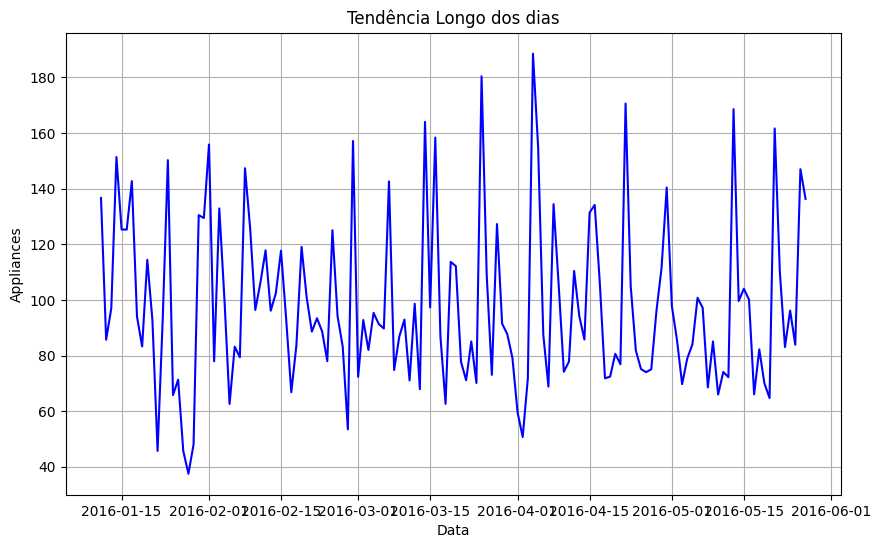

In [90]:
df_energy_data_group_by_date= df_energy_data.copy()
df_energy_data_group_by_date['simple_date'] = df_energy_data_group_by_date['date'].apply(lambda x: pd.to_datetime(str(x)[:10]))

df_energy_data_group_by_date = (
    df_energy_data_group_by_date.groupby(["simple_date"])
    .agg({"Appliances": "mean"})
    .reset_index()
)

# Plotar a tendência de consumo ao longo dos anos
plt.figure(figsize=(10, 6))
plt.plot(
    df_energy_data_group_by_date["simple_date"],
    df_energy_data_group_by_date["Appliances"],
    # marker="o",
    linestyle="-",
    color="b",
)
plt.xlabel("Data")
plt.ylabel("Appliances")
plt.title("Tendência Longo dos dias")
plt.grid(True)
plt.show()


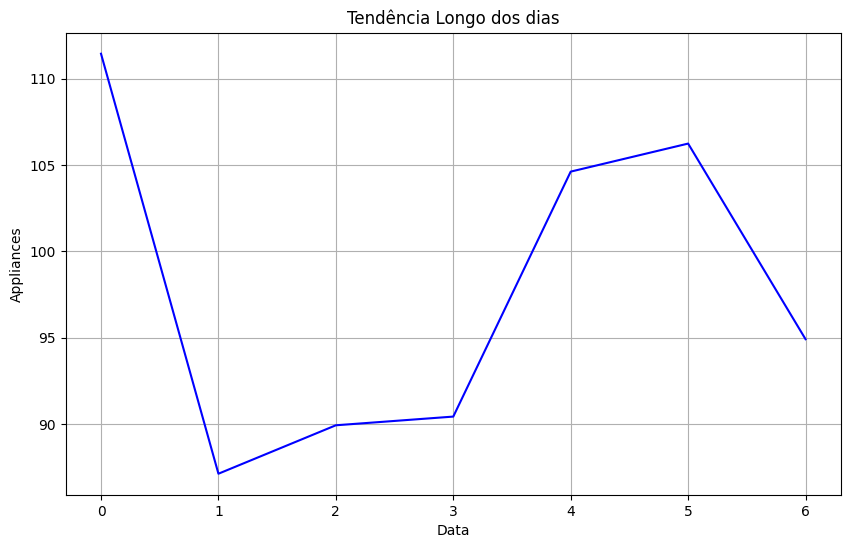

In [91]:
df_energy_data_group_by_day = df_energy_data.copy()

df_energy_data_group_by_day['week_day'] = df_energy_data_group_by_day['date'].apply(lambda x: datetime.date.weekday(x))

df_energy_data_group_by_day = (
    df_energy_data_group_by_day.groupby(["week_day"])
    .agg({"Appliances": "mean"})
    .reset_index()
)

# Plotar a tendência de consumo ao longo dos anos
plt.figure(figsize=(10, 6))
plt.plot(
    df_energy_data_group_by_day["week_day"],
    df_energy_data_group_by_day["Appliances"],
    # marker="o",
    linestyle="-",
    color="b",
)
plt.xlabel("Data")
plt.ylabel("Appliances")
plt.title("Tendência Longo dos dias")
plt.grid(True)
plt.show()


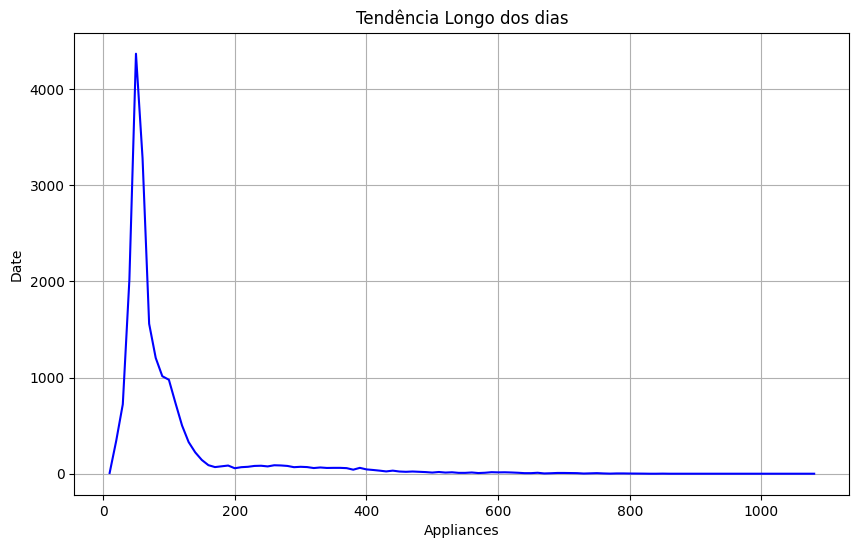

In [92]:
df_energy_data_group_by_applinances= df_energy_data.copy()

df_energy_data_group_by_applinances = (
    df_energy_data_group_by_applinances.groupby(["Appliances"])
    .agg({"date": "count"})
    .reset_index()
)

# Plotar a tendência de consumo ao longo dos anos
plt.figure(figsize=(10, 6))
plt.plot(
    df_energy_data_group_by_applinances["Appliances"],
    df_energy_data_group_by_applinances["date"],
    # marker="o",
    linestyle="-",
    color="b",
)
plt.xlabel("Appliances")
plt.ylabel("Date")
plt.title("Tendência Longo dos dias")
plt.grid(True)
plt.show()

- Foi possível observar que a variável appliances tem um padrão semanal.
- O consumo tende a se concentrar em valores baixos
- Ao realizar o processo de tratamento de outliers, provável que os valores acima de 200 serão removidos do dataset

---

### 28. Correlações com variáveis ambientais

- Calcule correlações entre Appliances e variáveis como temperatura e umidade.
- Pergunta: quais fatores têm mais relação com o consumo?


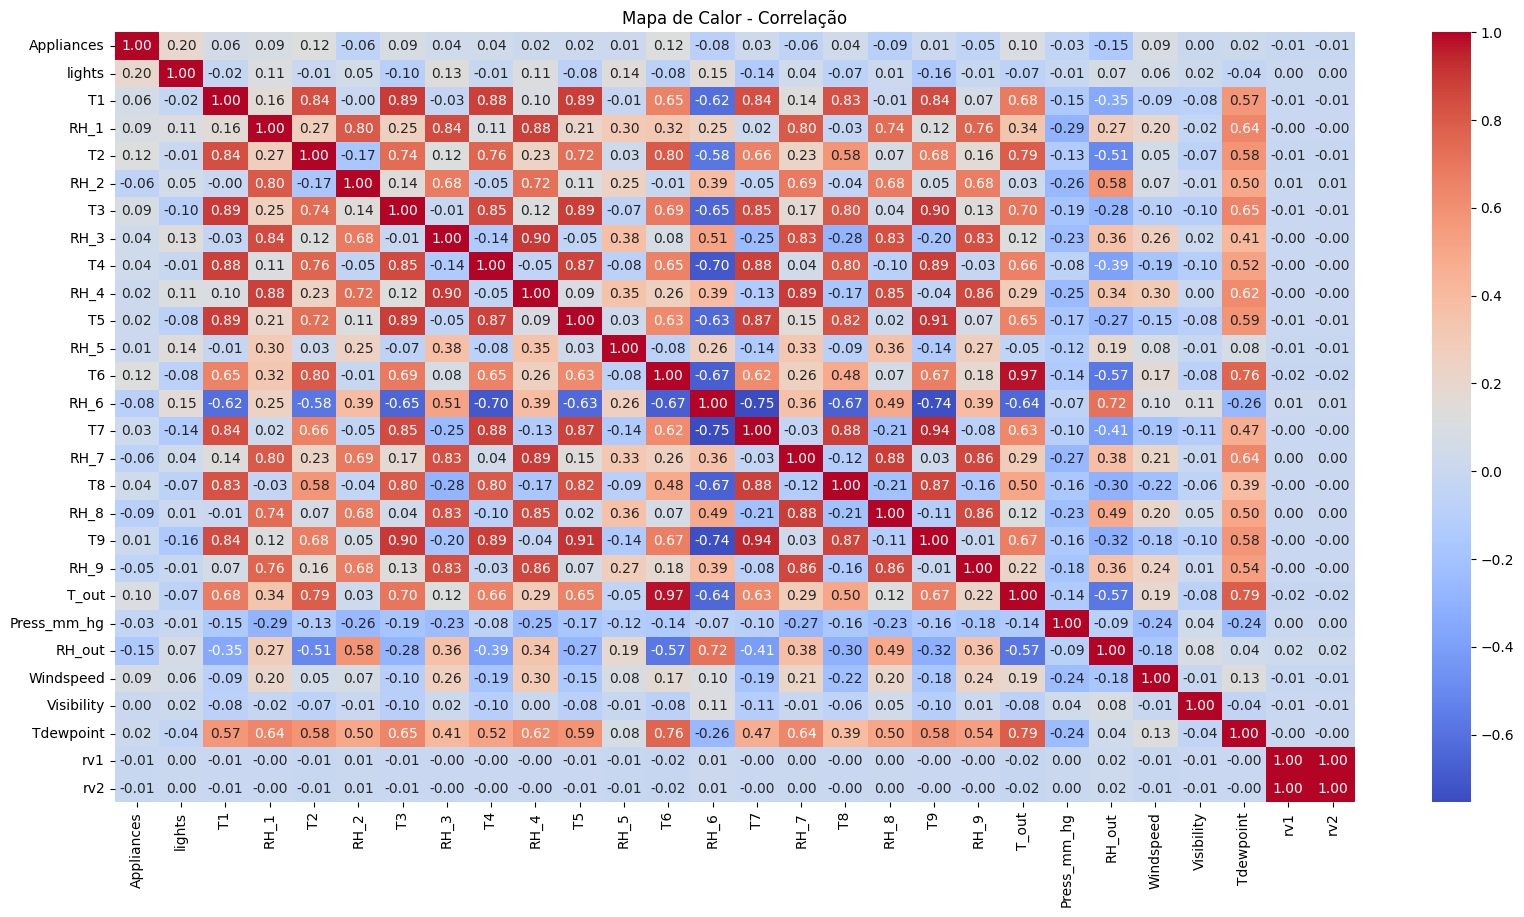

In [93]:
df_correlation = df_energy_data.select_dtypes(include=["number"])

# Calcula a matriz de correlação
corr = df_correlation.corr()

# Cria o mapa de calor
plt.figure(figsize=(20, 10))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm")

plt.title("Mapa de Calor - Correlação")
plt.show()

In [94]:
df_energy_data = df_energy_data.drop(columns=["rv1", "rv2", "Visibility"])
# essas variaveis estão gerando ruido no dataset

- **Nenhuma** variável tem correlação significativa com o uso de energia
- Os fatores que possuem mais relacionamento são as variáveis com correlação entre elas mesmas 

---

### 29. Normalização dos dados

- Aplique Min-Max Scaling às variáveis numéricas.
- Reutilize esses dados em modelos posteriores.


In [95]:
df_numeric = df_energy_data.select_dtypes(include=["number"])

# Criando o scaler
scaler = MinMaxScaler()

# Aplicando transformação
df_scaled = pd.DataFrame(
    scaler.fit_transform(df_numeric),
    columns=df_numeric.columns
)

df_scaled.head()

,Appliances,lights,T1,RH_1,T2,RH_2,T3,RH_3,T4,RH_4,...,RH_7,T8,RH_8,T9,RH_9,T_out,Press_mm_hg,RH_out,Windspeed,Tdewpoint
0,0.046729,0.428571,0.32735,0.566187,0.225345,0.684038,0.215188,0.746066,0.351351,0.764262,...,0.653428,0.173329,0.661412,0.223032,0.677290,0.372990,0.097674,0.894737,0.500000,0.538462
1,0.046729,0.428571,0.32735,0.541326,0.225345,0.682140,0.215188,0.748871,0.351351,0.782437,...,0.651064,0.173329,0.660155,0.226500,0.678532,0.369239,0.100000,0.894737,0.476190,0.533937
2,0.037383,0.428571,0.32735,0.530502,0.225345,0.679445,0.215188,0.755569,0.344745,0.778062,...,0.646572,0.173329,0.655586,0.219563,0.676049,0.365488,0.102326,0.894737,0.452381,0.529412
3,0.037383,0.571429,0.32735,0.524080,0.225345,0.678414,0.215188,0.758685,0.341441,0.770949,...,0.641489,0.164175,0.650788,0.219563,0.671909,0.361736,0.104651,0.894737,0.428571,0.524887
4,0.046729,0.571429,0.32735,0.531419,0.225345,0.676727,0.215188,0.758685,0.341441,0.762697,...,0.639362,0.164175,0.650788,0.219563,0.671909,0.357985,0.106977,0.894737,0.404762,0.520362



---

### 30. PCA

- Aplique PCA e reduza para 2 componentes principais.
- Plote os dados resultantes.
- Pergunta: aparecem padrões ou agrupamentos naturais?


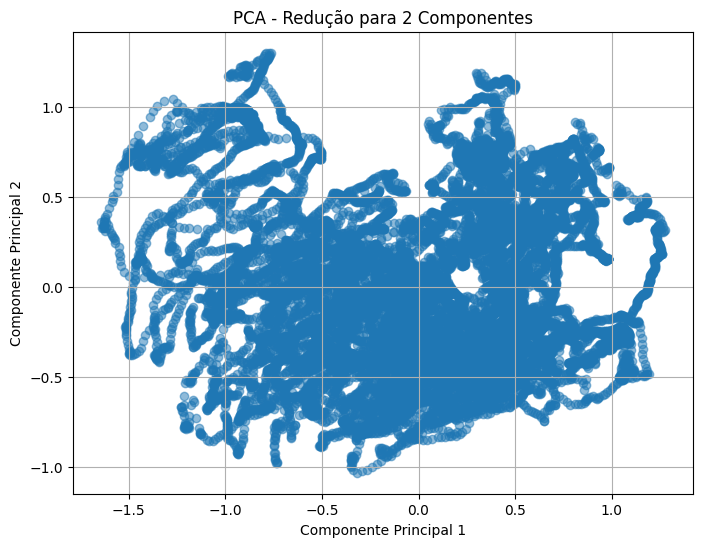

In [96]:


# PCA para 2 componentes principais
pca = PCA(n_components=2)
df_pca = pca.fit_transform(df_scaled)

# Criar DataFrame com resultados
df_pca = pd.DataFrame(df_pca, columns=["PC1", "PC2"])

# Plotando os dados no espaço PCA
plt.figure(figsize=(8,6))
plt.scatter(df_pca["PC1"], df_pca["PC2"], alpha=0.5)
plt.xlabel("Componente Principal 1")
plt.ylabel("Componente Principal 2")
plt.title("PCA - Redução para 2 Componentes")
plt.grid(True)
plt.show()

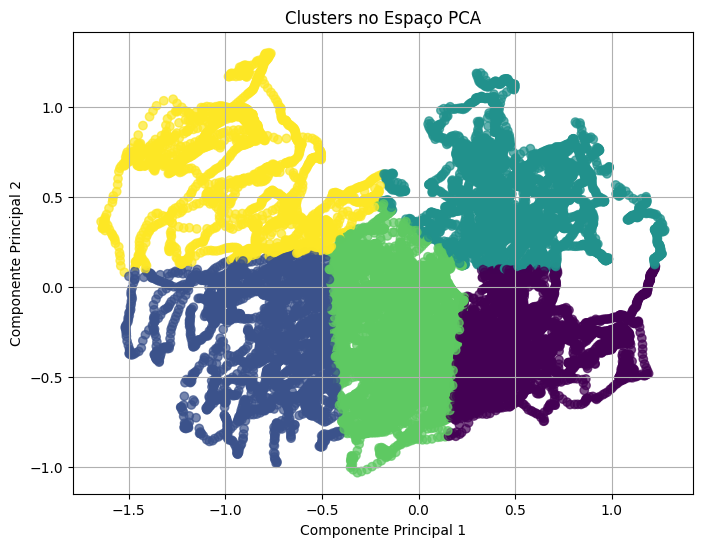

In [97]:
# Definir número de clusters
kmeans = KMeans(n_clusters=5, random_state=42)
clusters = kmeans.fit_predict(df_pca)

# Adicionar os clusters ao DataFrame PCA
df_pca["Cluster"] = clusters

# Plotar PCA com cores por cluster
plt.figure(figsize=(8,6))
plt.scatter(df_pca["PC1"], df_pca["PC2"], c=df_pca["Cluster"], cmap="viridis", alpha=0.7)
plt.xlabel("Componente Principal 1")
plt.ylabel("Componente Principal 2")
plt.title("Clusters no Espaço PCA")
plt.grid(True)
plt.show()


Não tiveram agrupamentos ou padrões naturais

> o uso do KMeans pode influenciar a decisão

---

### 31. Regressão Linear Múltipla

- Modele Appliances em função das variáveis ambientais.
- Avalie R² e erro médio.


In [98]:
# Separando X (variáveis ambientais) e y (consumo dos aparelhos)
X = df_scaled.drop(columns=["Appliances", "lights"])
y = df_scaled["Appliances"]

# Divisão treino/teste
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Treinando regressão linear múltipla
lin_reg = LinearRegression()
lin_reg.fit(X_train, y_train)

# Previsões
y_pred = lin_reg.predict(X_test)

# Avaliação
r2 = r2_score(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)

print("R²:", r2)
print("MSE:", mse)
print("RMSE:", rmse)

R²: 0.14562981884715975
MSE: 0.007467691703071982
RMSE: 0.08641580702089162


Apesar do erro médio baixo, o coeficiente R² indica que o modelo explica apenas uma pequena fração da variabilidade do consumo dos aparelhos.
usando como dataset o `df_scaled`, temos valores entre 0 e 1, então o erro **parece** pouco

O modelo de regressão linear não se aplica a esse dataset

---

### 32. Random Forest Regressor

- Treine um modelo de Random Forest para prever Appliances.
- Compare o RMSE com a regressão linear.


In [99]:
# X e y (mesmos da regressão linear)
X = df_scaled.drop(columns=["Appliances"])
y = df_scaled["Appliances"]

# Divisão treino/teste
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Modelo Random Forest
rf_reg = RandomForestRegressor(n_estimators=100, random_state=42)
rf_reg.fit(X_train, y_train)

# Previsões
y_pred_rf = rf_reg.predict(X_test)

# Avaliação
r2_rf = r2_score(y_test, y_pred_rf)
mse_rf = mean_squared_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mse_rf)

print("Random Forest - R²:", r2_rf)
print("Random Forest - MSE:", mse_rf)
print("Random Forest - RMSE:", rmse_rf)


Random Forest - R²: 0.5382617578686459
Random Forest - MSE: 0.004035860468705323
Random Forest - RMSE: 0.06352842252649851


O Random Forest se sai melhor explicando 50% das variáveis, mas ainda não é um bom resultado resultado para um modelo preditivo.


In [100]:
# Separando X (variáveis ambientais) e y (consumo dos aparelhos)
X = df_numeric.drop(columns=["Appliances", "lights"])
y = df_numeric["Appliances"]

# Divisão treino/teste
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Treinando regressão linear múltipla
lin_reg = LinearRegression()
lin_reg.fit(X_train, y_train)

# Previsões
y_pred = lin_reg.predict(X_test)

# Avaliação
r2 = r2_score(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)

print("R²:", r2)
print("MSE:", mse)
print("RMSE:", rmse)

R²: 0.14562981884715998
MSE: 8549.76023084711
RMSE: 92.46491351235403


> por curiosidade 
usar o modelo escalonado ou com os valores originais, `não altera o R²`, porem dados escalonados são mais fáceis para processamento

---

### 33. K-Means clustering
- Aplique K-Means com 3 a 5 clusters.
- Interprete os perfis de consumo.

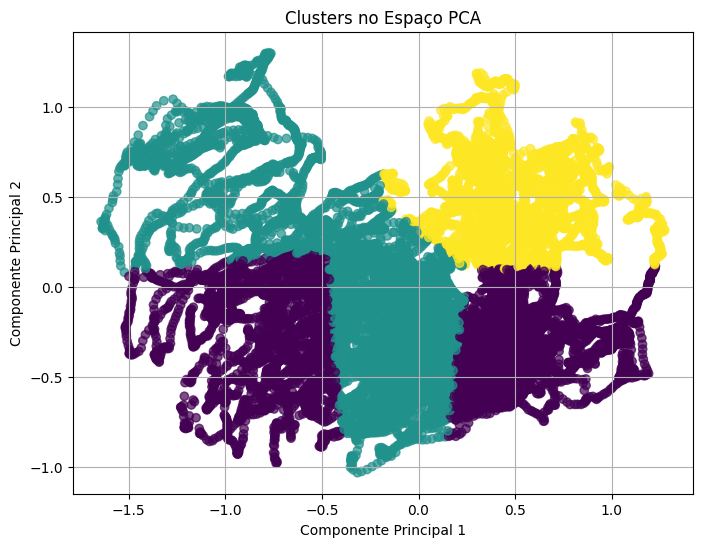

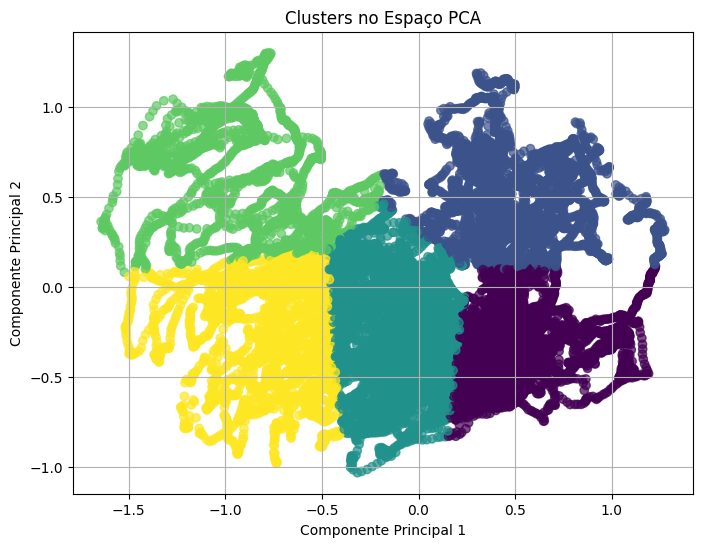

In [101]:
# Definir número de clusters
kmeans = KMeans(n_clusters=3, random_state=42)
clusters = kmeans.fit_predict(df_pca)

# Adicionar os clusters ao DataFrame PCA
df_pca["Cluster"] = clusters

# Plotar PCA com cores por cluster
plt.figure(figsize=(8,6))
plt.scatter(df_pca["PC1"], df_pca["PC2"], c=df_pca["Cluster"], cmap="viridis", alpha=0.7)
plt.xlabel("Componente Principal 1")
plt.ylabel("Componente Principal 2")
plt.title("Clusters no Espaço PCA")
plt.grid(True)
plt.show()

# Definir número de clusters
kmeans = KMeans(n_clusters=5, random_state=42)
clusters = kmeans.fit_predict(df_pca)

# Adicionar os clusters ao DataFrame PCA
df_pca["Cluster"] = clusters

# Plotar PCA com cores por cluster
plt.figure(figsize=(8,6))
plt.scatter(df_pca["PC1"], df_pca["PC2"], c=df_pca["Cluster"], cmap="viridis", alpha=0.7)
plt.xlabel("Componente Principal 1")
plt.ylabel("Componente Principal 2")
plt.title("Clusters no Espaço PCA")
plt.grid(True)
plt.show()


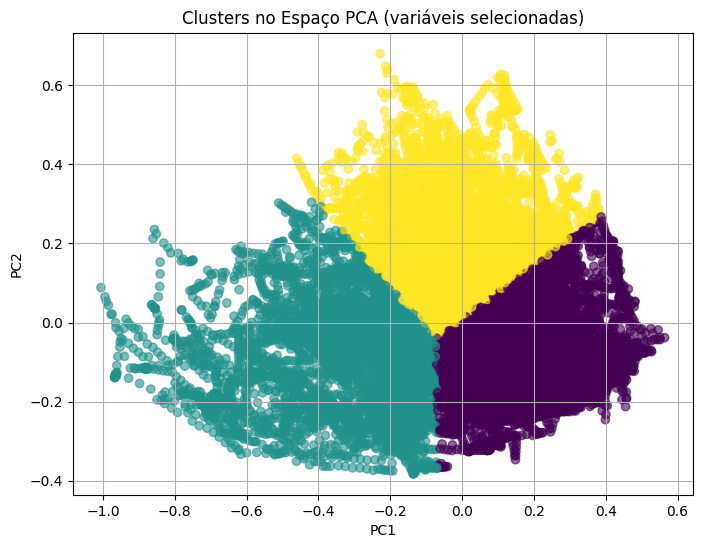

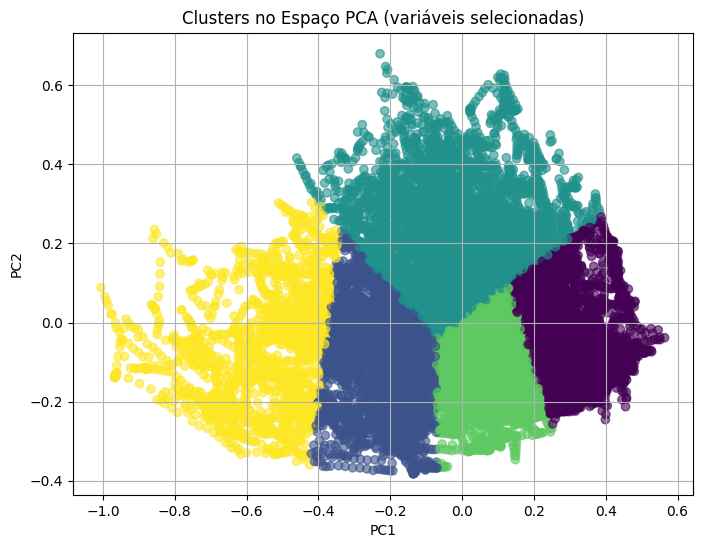

In [102]:
# Selecionar só algumas variáveis relevantes
selected_cols = ["Appliances", "lights", "T1", "RH_1", "T_out", "RH_out", "Windspeed"]

df_selected = df_scaled[selected_cols]

# PCA de 2 componentes
pca = PCA(n_components=2)
df_pca = pca.fit_transform(df_selected)

df_pca = pd.DataFrame(df_pca, columns=["PC1", "PC2"])

# KMeans com 3 clusters 
kmeans = KMeans(n_clusters=3, random_state=42)
clusters = kmeans.fit_predict(df_pca)

df_pca["Cluster"] = clusters

# Plotar
plt.figure(figsize=(8,6))
plt.scatter(df_pca["PC1"], df_pca["PC2"], c=df_pca["Cluster"], cmap="viridis", alpha=0.6)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Clusters no Espaço PCA (variáveis selecionadas)")
plt.grid(True)
plt.show()

# KMeans com 5 clusters 
kmeans = KMeans(n_clusters=5, random_state=42)
clusters = kmeans.fit_predict(df_pca)

df_pca["Cluster"] = clusters

# Plotar
plt.figure(figsize=(8,6))
plt.scatter(df_pca["PC1"], df_pca["PC2"], c=df_pca["Cluster"], cmap="viridis", alpha=0.6)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Clusters no Espaço PCA (variáveis selecionadas)")
plt.grid(True)
plt.show()


In [103]:
print(pca.explained_variance_ratio_)
print("Variância total explicada:", sum(pca.explained_variance_ratio_))

[0.41900929 0.20391496]
Variância total explicada: 0.6229242470405738


In [104]:
loadings = pd.DataFrame(pca.components_.T, columns=["PC1", "PC2"], index=df_selected.columns)
print(loadings)

                 PC1       PC2
Appliances -0.057989  0.059568
lights      0.029971  0.067173
T1         -0.480798 -0.416391
RH_1       -0.041284  0.060350
T_out      -0.594835 -0.055016
RH_out      0.617513 -0.130459
Windspeed  -0.166487  0.891555


#### PC1 (principal):

- Forte influência de T_out (-0.59) -> temperatura externa.
- Forte influência de RH_out (+0.61) -> umidade externa.
- Também bastante peso em T1 (-0.48) -> temperatura interna (cozinha).
  Ou seja, PC1 representa a relação entre calor/frio interno vs externo junto da umidade.

#### PC2 (secundário):

- Forte influência de Windspeed (+0.89) -> velocidade do vento.
- Também influência de T1 (-0.42) -> temperatura interna.
  PC2 parece capturar efeitos de vento + temperatura interna.

#### Appliances e Lights:

- Influencia próxima de zero -> de fato, não têm quase nenhuma contribuição para esses 2 primeiros PCs.
  Isso significa que o consumo dos aparelhos/luzes não está explicando a maior parte da variação geral dos dados. O que mais varia, no dataset, são as condições ambientais.


---

### 34. Classificação binária

- Crie uma variável: alto vs baixo consumo (Appliances maior/menor que a mediana).
- Treine Logistic Regression e Random Forest Classifier.


In [105]:
median_appliances = df_scaled["Appliances"].median()
df_scaled["consumo"] = df_scaled["Appliances"].apply(
    lambda x: 1 if x > median_appliances else 0
)
df_scaled.head()

,Appliances,lights,T1,RH_1,T2,RH_2,T3,RH_3,T4,RH_4,...,T8,RH_8,T9,RH_9,T_out,Press_mm_hg,RH_out,Windspeed,Tdewpoint,consumo
0,0.046729,0.428571,0.32735,0.566187,0.225345,0.684038,0.215188,0.746066,0.351351,0.764262,...,0.173329,0.661412,0.223032,0.677290,0.372990,0.097674,0.894737,0.500000,0.538462,0
1,0.046729,0.428571,0.32735,0.541326,0.225345,0.682140,0.215188,0.748871,0.351351,0.782437,...,0.173329,0.660155,0.226500,0.678532,0.369239,0.100000,0.894737,0.476190,0.533937,0
2,0.037383,0.428571,0.32735,0.530502,0.225345,0.679445,0.215188,0.755569,0.344745,0.778062,...,0.173329,0.655586,0.219563,0.676049,0.365488,0.102326,0.894737,0.452381,0.529412,0
3,0.037383,0.571429,0.32735,0.524080,0.225345,0.678414,0.215188,0.758685,0.341441,0.770949,...,0.164175,0.650788,0.219563,0.671909,0.361736,0.104651,0.894737,0.428571,0.524887,0
4,0.046729,0.571429,0.32735,0.531419,0.225345,0.676727,0.215188,0.758685,0.341441,0.762697,...,0.164175,0.650788,0.219563,0.671909,0.357985,0.106977,0.894737,0.404762,0.520362,0


In [106]:
# Separar variáveis explicativas (X) e alvo (y)
X = df_scaled.drop(columns=["Appliances", "consumo"])
y = df_scaled["consumo"]

# Divisão treino/teste
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Modelo 1 - Regressão Logística
log_reg = LogisticRegression(max_iter=1000)
log_reg.fit(X_train, y_train)
y_pred_log = log_reg.predict(X_test)

# Modelo 2 - Random Forest
rf_clf = RandomForestClassifier(n_estimators=100, random_state=42)
rf_clf.fit(X_train, y_train)
y_pred_rf = rf_clf.predict(X_test)

# Avaliação
print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_log))
print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))

print("\n--- Logistic Regression Report ---")
print(classification_report(y_test, y_pred_log))

print("\n--- Random Forest Report ---")
print(classification_report(y_test, y_pred_rf))


Logistic Regression Accuracy: 0.763617937674183
Random Forest Accuracy: 0.899417278946035

--- Logistic Regression Report ---
              precision    recall  f1-score   support

           0       0.77      0.80      0.78      2127
           1       0.75      0.72      0.74      1820

    accuracy                           0.76      3947
   macro avg       0.76      0.76      0.76      3947
weighted avg       0.76      0.76      0.76      3947


--- Random Forest Report ---
              precision    recall  f1-score   support

           0       0.90      0.92      0.91      2127
           1       0.90      0.88      0.89      1820

    accuracy                           0.90      3947
   macro avg       0.90      0.90      0.90      3947
weighted avg       0.90      0.90      0.90      3947



In [107]:
importances = rf_clf.feature_importances_
features = X.columns
sorted_importances = sorted(zip(features, importances), key=lambda x: x[1], reverse=True)

for feat, imp in sorted_importances[:10]:  # top 10
    print(f"{feat}: {imp:.4f}")


RH_8: 0.0655
lights: 0.0606
RH_out: 0.0597
T2: 0.0576
RH_9: 0.0547
RH_5: 0.0487
RH_6: 0.0485
T6: 0.0432
RH_1: 0.0417
Press_mm_hg: 0.0416


Foram treinados dois modelos de classificação binária para prever alto/baixo consumo de aparelhos (Appliances), definido pela mediana.

A Regressão Logística obteve 76% de acurácia, enquanto o Random Forest alcançou 90%, demonstrando melhor capacidade de capturar relações não lineares entre variáveis ambientais e consumo.

#### Observação!

Dentre as variáveis que mais tiveram participação no treinamento, Appliances não está nelas, o que pode gerar problemas na interpretação das previsões

---

### 35. Avaliação de classificação

- Gere matriz de confusão e métricas (accuracy, precision, recall, F1-score).
- Pergunta: o modelo erra mais para alto ou para baixo consumo?


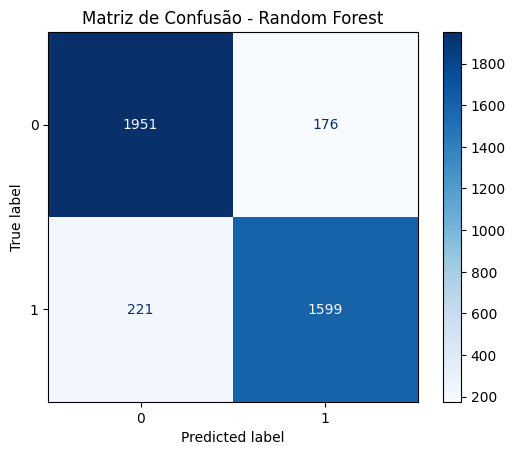


--- Random Forest Report ---
              precision    recall  f1-score   support

           0       0.90      0.92      0.91      2127
           1       0.90      0.88      0.89      1820

    accuracy                           0.90      3947
   macro avg       0.90      0.90      0.90      3947
weighted avg       0.90      0.90      0.90      3947



In [108]:

# Para o Random Forest (melhor modelo)
cm = confusion_matrix(y_test, y_pred_rf)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0,1])
disp.plot(cmap="Blues")
plt.title("Matriz de Confusão - Random Forest")
plt.show()

print("\n--- Random Forest Report ---")
print(classification_report(y_test, y_pred_rf))


Se a gente olha quem mais sofre erro -> o modelo tem mais dificuldade em identificar alto consumo, porque 221 altos foram confundidos com baixos.

Mas se a gente olha o padrão de arredondamento do modelo → “na dúvida, ele tende a marcar como baixo”, porque errou mais vezes jogando valores da classe 1 para a classe 0.
